In [7]:
import pandas as pd

In [12]:
df = pd.read_excel("assignment.xlsx")

In [13]:
df.head()

,OBJECTID,Company,Address,City,State,ZipCode,Better_Lat,Better_Long,SquareFeet,Common_Name,...,FAX,EMAIL,WEBSITE,DIG_MEMBER,Data_Source,Centroid_X,Centroid_Y,ORIG_FID,Spring_Sales(Dollar),Fall_Sales(Dollar)
0,1,NAFSU ENTERPRISES INC ...,10320 PLYMOUTH RD ...,DETROIT,MI,48204,42.373652,-83.162775,15879.452103,Shop A Lot Food Center,...,NaN,NaN,NaN,NaN,NETS/Devries,-83.162894,42.373634,1,32679.904207,44165.520679
1,2,RED FOX FOODLAND ...,10333 FENKELL ST ...,DETROIT,MI,48238,42.402180,-83.163377,16130.740855,Red Fox Foodland,...,NaN,NaN,NaN,NaN,NETS/Devries,-83.163460,42.402178,2,41825.852139,45746.000310
2,3,X Z INC ...,11100 MACK AVE ...,DETROIT,MI,48214,42.377829,-82.980885,14160.290542,NaN,...,NaN,NaN,NaN,NaN,NETS/Devries,-82.980411,42.378031,3,29432.581083,25829.493921
3,4,UNIVERSITY FOOD CENTER INC ...,1131 W WARREN AVE ...,DETROIT,MI,48201,42.353200,-83.074400,22100.821554,University Foods,...,(313) 833-5648,nyaldoo@spartanstores.com,http://universityfoodsmidtown.com/,Yes,NETS/Devries,-83.074478,42.352644,4,45149.643108,39079.396642
4,5,SAVE A LOT ...,11825 WOODWARD AVE,DETROIT,MI,48203,42.393700,-83.089300,16124.320667,Save A Lot,...,NaN,NaN,NaN,NaN,NETS/Devries,-83.089592,42.393828,5,33673.641334,28851.345134


In [14]:
average_area = df['SquareFeet'].mean()

In [15]:
average_area

2253022.9654016416

In [16]:
import numpy as np
import matplotlib.pyplot as plt

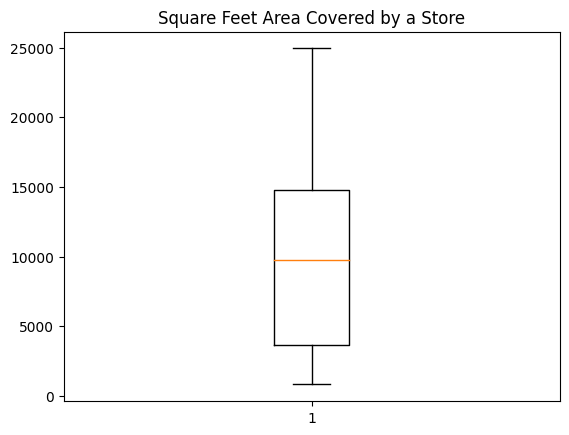

In [17]:
median = np.median(df['SquareFeet'])
median_absolute_deviation = np.median(np.abs(df['SquareFeet'] - median))
threshold = 3 * median_absolute_deviation
outliers_median = df['SquareFeet'][np.abs(df['SquareFeet'] - median) > threshold]

# Drop rows with outliers
df = df.drop(df[df['SquareFeet'].isin(outliers_median)].index)

# Find outliers using IQR method
q1 = df['SquareFeet'].quantile(0.25)
q3 = df['SquareFeet'].quantile(0.75)
iqr = q3 - q1
threshold = 1.5 * iqr
outliers_iqr = df['SquareFeet'][(df['SquareFeet'] < q1 - threshold) | (df['SquareFeet'] > q3 + threshold)]

# Create boxplot to visualize outliers
plt.boxplot(df['SquareFeet'])
plt.title("Square Feet Area Covered by a Store")
plt.show()

In [20]:

from scipy.stats import skew
skewness = skew(df['SquareFeet'])

print("The skewness of the SquareFeet area of stores is:", skewness)


The skewness of the SquareFeet area of stores is: 0.4571945236190921


In [33]:
# Create subset of stores with area less than 7000 sqft
subset = df[df['SquareFeet'] < 7000]

# Calculate mean sales for fall and spring seasons
mean_fall_sales = subset['Fall_Sales(Dollar)'].mean()
mean_spring_sales = subset['Spring_Sales(Dollar)'].mean()

# Compare with sales of new store
new_store_area = 3954
new_store_fall_sales = 20123.1
new_store_spring_sales = 19541.3

if new_store_area < 7000:
    if new_store_fall_sales > mean_fall_sales:
        print("The new store earned the most in fall season compared to other stores with the same area.")
    elif new_store_spring_sales > mean_spring_sales:
        print("The new store earned the most in spring season compared to other stores with the same area.")
    else:
        print("The new store did not earn the most in either season compared to other stores with the same area.")
else:
    print("The new store area is not less than 7000 sqft.")


The new store earned the most in fall season compared to other stores with the same area.


In [34]:
corr_coef = pd['Area'].corr(pd['Winter_Sales'])
print('The Pearson correlation coefficient between the area of the store and winter sales is:', corr_coef)



TypeError: ignored